# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 10</span>

### Exercise 10.1

Choose **ONLY ONE** of the two following possibilities:

1. Parallelize with MPI libraries your Genetic Algorithm code in order to solve the TSP by performing a *Genetic Search* with (up to) 11 **parallel GA searches of the optimal path**:
each node should perform an independent GA search, the so-called *Continent*, **but** every $N_{migr}$ generations the *Continents* should exchange their best individuals randomly.

2. Starting from your Genetic Algorithm code implement a **Parallel Tempering algorithm** (Simulated Annealing with many temperatures). Parallelize with MPI libraries your algorithm in order to solve the TSP where each computing node, up to 11, is characterized by a different temperature or a limited set of temperatures (if you need more than 11 temperatures). Use your genetic operators (except crossover) as trial moves for the Metropolis algorithm and **add a trial move that proposes an exchange of paths among adjacent temperatures (nodes)** (see lecture 8 for the acceptance formula). The candidate solution of the TSP will appear on the node with the lowest temperature.

### Exercise 10.2

Apply your parallel code to the TSP problem for 110 italian "capoluoghi di provincia" longitude and latitude coordinates in the *cap_prov_ita.dat* file.

If your choice in Exercise 10.1 is option 1, do you improve with respect using the same number of computing cores but with **independent GA searches** ?

If your choice in Exercise 10.1 is option 2, by using a number of temperatures equal to the number of individuals in your **non-parallel Genetic Algorithm code**, do you "improve" with respect to it?

## **Submission**


### **Exercise 10.1**
#### **Introduction**
I decided to implement the first possibility, so I implemented an algorithm that creates $N_{continents}$ that each represent an independent MPI process that after $N_{generations}$ of the GA algorithms exchange their best individuals. To verify the goodness of the parallel GA searches I used the **circle** and **square** configurations. I decided to plot the Loss function of the best half of the population and of the best individual only for the process that found the shortest trajectory rather than saving the data for all processes. In the file `OUTPUT/ranking_processes.dat` can be found the rank with the distance relative to it's shortest path and in `OUTPUT/BestTrajectory.dat` 
I saved the the shortest paths for the different MPI processes (the paths after the $N_{processes}$ trajectories are different individuals for the rank = 0). 
**NOTE**: The following plots are done for the best paths out of all MPI processes, both loss functions are calculated and plotted for the MPI process with the shortest final trajectory. 

#### **Code Implementation**
Most of the new functions that I wrote for this exercise are stored in `lib.h`. I implemented functions such as `create_folders` or `paste_shortest_rank` which very intuitive and don't require an explanation.
The first and most important thing to do to have a functioning parallel computation is to implement the random number generator differently for each process, so that the processes are parallel and independent, and thus obtain different results. To do so I implemented the following functions: 
```cpp
void initialize_rand(Random &_rnd, int &rank)
{
    int p1, p2; // Read from ../INPUT/Primes a pair of numbers to be used to initialize the RNG
    ifstream Primes("../INPUT/Primes");

    // Salta le righe precedenti in base al rank del processo
    for(int i = 0; i <= rank; i++) {
        Primes >> p1 >> p2;
    }
    Primes.close();

    int seed[4]; // Read the seed configuration array of the RNG
    ifstream Seed("../INPUT/seed.in");
    Seed >> seed[0] >> seed[1] >> seed[2] >> seed[3];

    // The seed for each rank is different, so I have independent processes
    seed[0] += rank;
    seed[1] += rank;
    _rnd.SetRandom(seed, p1, p2);
}
```
In this way the seed is different for each rank. 

--- 
#### **Organizing the parallel computation**

To swap the best trajectories between different MPI processes, I implemented a cyclical exchange algorithm. The code determines a random integer shift $s \in [1, N_{\text{processes}}]$, which represents the distance between the sending and receiving ranks. For example, if $s = 5$ and $\text{Rank}_{\text{send}} = 1$, then $\text{Rank}_{\text{receive}} = 6$,  $\text{Rank}_{\text{send}} = 2$ and $\text{Rank}_{\text{receive}} = 7$ and so on...

The algorithm handles periodic boundary conditions using modular arithmetic; for instance, with 11 processes, if $s = 5$ and $\text{Rank}_{\text{send}} = 10$, then $\text{Rank}_{\text{receive}} = 4$. An important thing I had to decide was after how many generations I allow the processes to exchange best trajectories: giving too little time wouldn't allow for the genetic algorithm to do it's work due to receiving and sending schizofrenically. Giving too much time would result in not using effectively the power of parallel computation. 
```cpp
// Function to exchange the best trajectories between MPI processes
void exchange_best_trajectories(TSP &GA, int rank, int size, Random &_rnd, int generation_count, trajectory &path_to_send, trajectory &path_to_recv, int worst_index, int n_cities)
{
    if (generation_count % 100 == 0)
    {
        // Variable in which I save the best trajectory for a specific MPI process
        path_to_send = GA.getSpecTrajectory(0); 
        int shift;
        
        if (rank == 0)
        {
            //Because I only need to find the shift value once and then send it to the other MPI processes
            shift = int(_rnd.Rannyu(1, size));
        }

        // Send to all the process the shift value 
        MPI_Bcast(&shift, 1, MPI_INT, 0, MPI_COMM_WORLD);

        // Each process find the send and receiving rank
        int target_send = (rank + shift) % size;
        int target_recv = (rank - shift + size) % size;

        // Sends and receives onto path_to_recv the information stored in path_to_send from the process target_send
        // to the process target_recv
        MPI_Sendrecv(path_to_send.data(), n_cities, MPI_INT, target_send, 0,
                     path_to_recv.data(), n_cities, MPI_INT, target_recv, 0,
                     MPI_COMM_WORLD, MPI_STATUS_IGNORE);

        // Save in the place of the worst vector of the population the received path and then order the population
        GA.setSpecTrajectory(worst_index, path_to_recv);
        GA.reorder();
    }
}
```

--- 
### **Saving the results**
Another important function that I implemented was `int find_shortest_MPI(TSP &GA, int rank, int size)` which is a function that finds the rank that contains the trajectory with the shortest distance out of all the ranks. Essentially I used a function of the **MPI library** callled `MPI_Gather()` that from each MPI process gathers information from each MPI process (explained more in detail below). 

```cpp
// Function to find shortest MPI process
int find_shortest_MPI(TSP &GA, int rank, int size)
{
    
    double local_dist = GA.tot_dist_of_trajectory(GA.getSpecTrajectory(0););
    int min;

    vector<double> all_distances;
    if (rank == 0)
    {
        all_distances.resize(size);
    }

    // MPI_Gather function
    /*
    1. the variable that I need to send from each MPI_Process
    2. how many elements the each process has to send
    3. the type of variable each process sends in local_dist
    4. in which variable I need to save the MPI processed
    5. the amount of variables that have to be saved from each MPI process
    6. the type of variables that have to be saved inside
    ...

    IMPORTANT: the interesting thing about Gather is that in the i-cell of the vector all_distances is saved the distance of the i-rank so that there is no ambiguity
    otherwise there would have been a problem when saving the data because otherwise 5th element of all_distance might have been a distance relative to the 8th rank.
    The ambiguity is because the MPI process don't execute the programm in order, but gather saves the variables in order.
    */
    MPI_Gather(&local_dist, 1, MPI_DOUBLE, all_distances.data(), 1, MPI_DOUBLE, 0, MPI_COMM_WORLD);

    if (rank == 0)
    {
        ofstream out;
        // save the distance of shortest path for each MPI process on file
        out.open("../OUTPUT/ranking_processes.dat");
        out << "--- PROCESS RANKING (SHORTEST TRAJECTORIES) ---" << endl;
        for (int i = 0; i < size; ++i)
        {
            out << "Process/Continent Rank " << i << " -> Best Distance: " << all_distances[i] << endl;
        }
        out.close();
        min = 0;
        double min_dist = all_distances[0];
        for (int i = 0; i < size; i++)
        {
            if (min_dist > all_distances[i])
            {
                min_dist = all_distances[i];
                min = i;
            }
        }
    }
    //This function sends to all the MPI processes the rank of the process that has the shortest distance
    MPI_Bcast(&min, 1, MPI_INT, 0, MPI_COMM_WORLD);
    return min;
}
```

I also wrote a function called `save_best_trajectories` that saves in the first $N_{processes}$ rows of the population of rank 0 the best trajectory of each process (in the other rows there are the remaining $N_{population} - N_{processes}$ of the process of rank $0$) in order to then plot the different processes. Then I paste the population of rank 0 in `OUTPUT/BestTrajectories`.

```cpp
void save_best_trajectories(TSP &GA, int rank, int size, trajectory &path_to_send, trajectory &path_to_recv, int worst_index, int n_cities){
    // Variable on which I save the best path for each rank
    path_to_send = GA.getSpecTrajectory(0);
    if (rank != 0)
    {
        MPI_Send(path_to_send.data(), n_cities, MPI_INT, 0, 1, MPI_COMM_WORLD);
    }
    else
    {
        // Rank 0 sequentially saves elite paths from every worker to determine the global minimum
        for (int proc = 1; proc < size; proc++)
        {
            // Receive function, I have to change each time from which process I receive
            MPI_Recv(path_to_recv.data(), n_cities, MPI_INT, proc, 1, MPI_COMM_WORLD, MPI_STATUS_IGNORE);
            // Temporarily queue the incoming foreign path at the bottom of the population
            GA.setSpecTrajectory(worst_index, path_to_recv);
            // Sort immediately in order to have the recently save best path immediately shift up
            GA.reorder();
        }
        string send_destination = "../OUTPUT/BestTrajectories.dat";
        GA.paste_population(send_destination);
    }
}
```


I made a couple of key assumptions during the implementation:

* **First**, I assumed that the `create_folders` routine—executed exclusively by `rank == 0`—completes before any dependent operations begin, preventing the critical failure of generating the initial population before its storage directory exists.
* **Second**, I assumed that the shortest trajectory on any given process is consistently shorter than the longest trajectory across all other processes. If this assumption were violated, it would imply that valuable solutions are inadvertently being discarded during the parallel computation.


#### **Functions of the MPI library I used**
I used:
- `MPI_Gather`: this function saves the first variable passed in the function (in my case `&local_dist`) from each process onto the $4^{th}$ variable passed in the function which is `all_distances.data()`. Therefore, after `MPI_Gather` the vector `all_distances` has distance of the shortest trajectory of each process thus making its size the same amount of the number of ranks. 
- `MPI_Cast`: this function saves the variable `&min` (which is the rank of the process having the shortest distance) onto all the different MPI processes, this allows all processes to return `min` when the function `find_shortest_MPI` is called. 
- `MPI_Send` and `MPI_Recv`: I use these functions in `save_best_trajectories`. I use `MPI_Send` to send the shortest trajectory of each process different from the process of rank 0 to the process of rank 0. On the other hand I used `MPI_Recv` to receive onto rank 0 from the other processes the sent variables. I then saved them in place of the worst trajectory of that process and then reordered the population.
- `MPI_Sendrecv`: which I used to make the processes comunicate in exchanging their best trajectories, this function allows to send and receive information from 2 different ranks without having to worry about deadlocks.

🎉 Griglia formale dei percorsi salvata con successo in: IMAGES/CIRCLEPaths.png


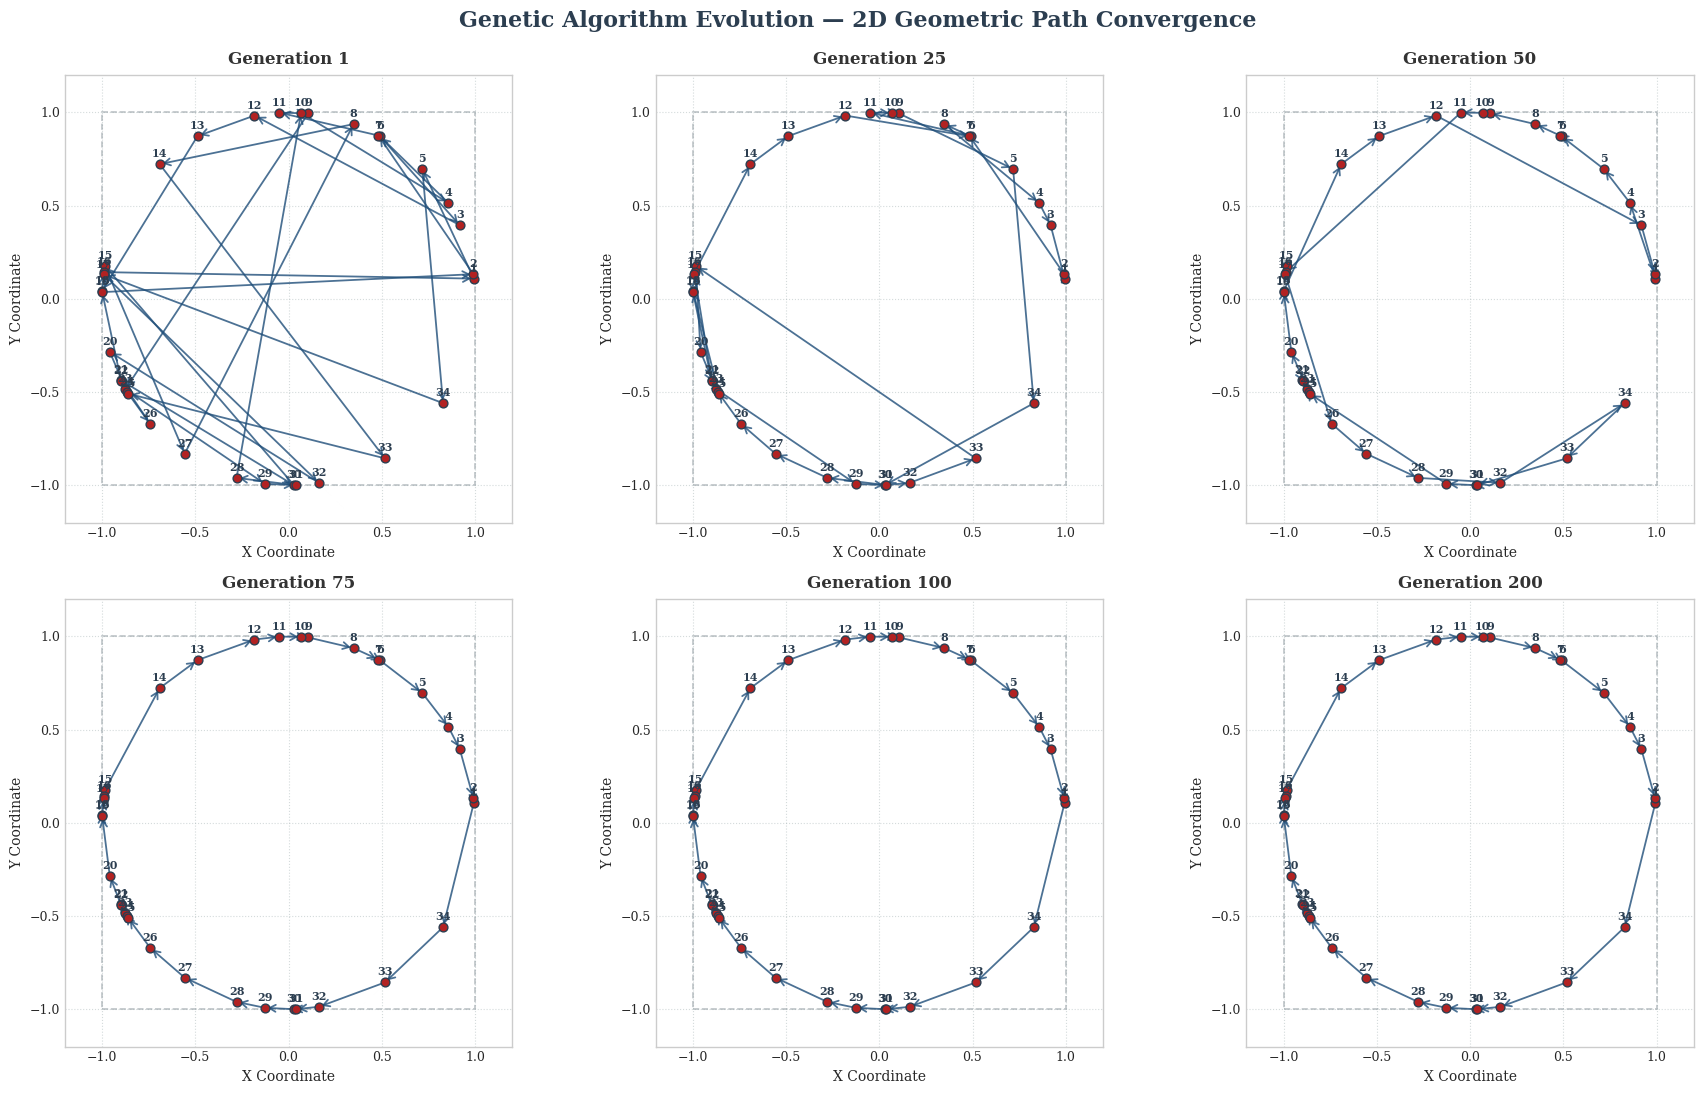


Caricamento dati di loss (CIRCLE)...
🎉 Grafico formale delle loss salvato con successo in: IMAGES/LossFunctionCircle.png


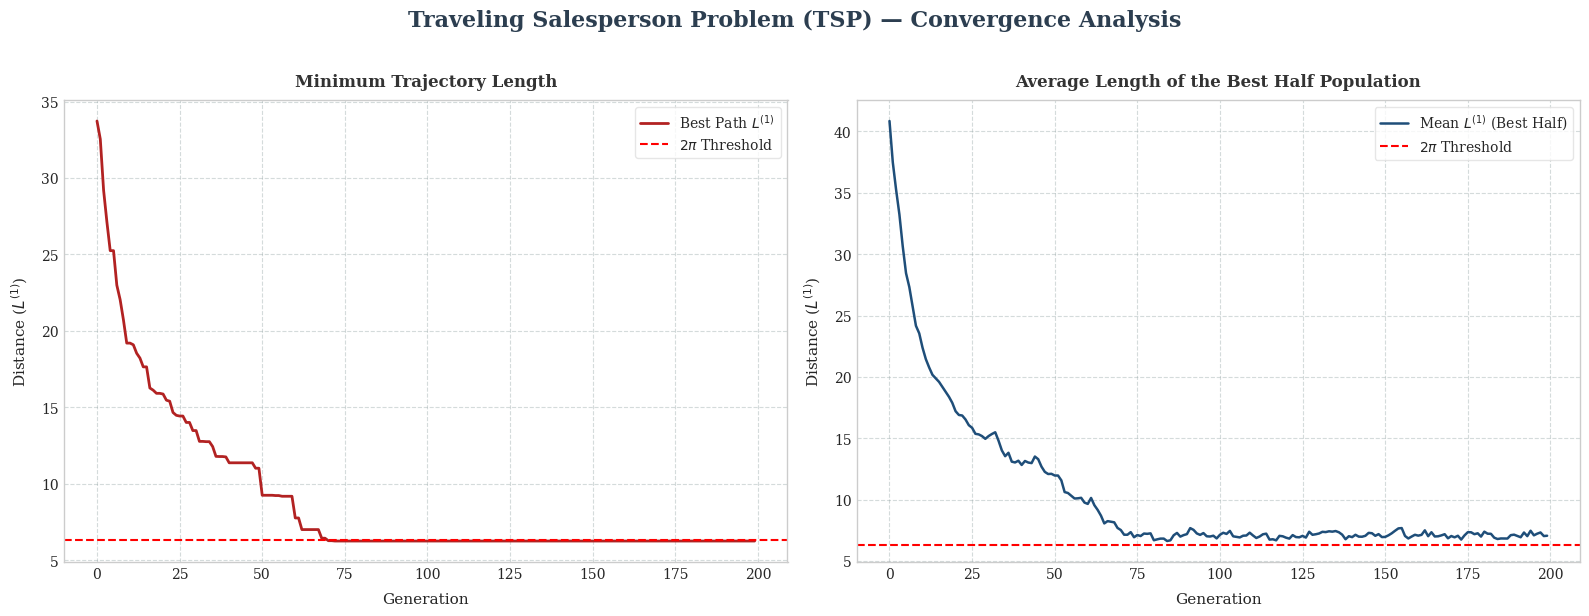

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# --- CONFIGURAZIONE PERCORSI ---
BASE_DIR = "CIRCLE/OUTPUT/"
file_cities = os.path.join(BASE_DIR, "CitiesInfo.dat")
gen_folder = os.path.join(BASE_DIR, "GENERATIONS0/")

BEST_PATH = os.path.join(BASE_DIR, "STAT/BestL1.dat")
HALF_PATH = os.path.join(BASE_DIR, "STAT/HalfL1.dat")

# Generazioni selezionate per la griglia 2x3
generazioni_plot = [0, 24, 49, 74, 99, 199]
try:
    # 1. Caricamento coordinate spaziali delle città
    if not os.path.exists(file_cities):
        raise FileNotFoundError(f"File città non trovato: {file_cities}")
        
    try:
        dati = np.loadtxt(file_cities)
    except ValueError:
        print("⚠️ Trovata intestazione di testo in CitiesInfo.dat. La salto automaticamente.")
        dati = np.loadtxt(file_cities, skiprows=1)
        
    labels = dati[:, 0].astype(int)
    x = dati[:, 1]
    y = dati[:, 2]
    
    # Mappatura solida a doppia chiave (sia per indici 0-based che 1-based)
    city_coords = {}
    for i in range(len(labels)):
        lbl = int(labels[i])
        city_coords[lbl] = (x[i], y[i])
        city_coords[i] = (x[i], y[i])
    
    # --- CONFIGURAZIONE STILE FORMALE ---
    plt.rcParams['font.family'] = 'serif'
    COLOR_PATH = "#1f4e79"                 # Blu notte istituzionale per la traiettoria
    COLOR_CITY = "#b22222"                 # Rosso scuro accademico per le città
    GRID_STYLE = {'linestyle': ':', 'alpha': 0.4, 'color': '#95a5a6'}

    fig, axes = plt.subplots(2, 3, figsize=(18, 11)) 
    axes_flat = axes.flatten() 

    for idx, gen in enumerate(generazioni_plot):
        ax = axes_flat[idx]
        
        # Generazione dinamica del percorso file
        file_attuale = os.path.join(gen_folder, f"PopulationGeneration{gen}.dat")
        
        if not os.path.exists(file_attuale):
            print(f"⚠️ File mancante per Gen {gen}: {file_attuale}. Salto il subplot.")
            ax.set_title(f"Gen {gen} (Not Found)", fontsize=11, color='gray', fontstyle='italic')
            continue

        # Lettura file di percorso
        with open(file_attuale, 'r') as file:
            prima_riga = file.readline().strip()
            percorso_str = file.readline().strip() if "Distanze" in prima_riga else prima_riga
        
        ordine_visita = [int(num) for num in percorso_str.split() if num.strip().isdigit()]
        
        if ordine_visita:
            ordine_visita.append(ordine_visita[0]) # Chiusura del cammino hamiltoniano

        # Riferimento geometrico di sfondo (Quadrato di vincolo)
        quadrato = patches.Rectangle((-1.0, -1.0), 2.0, 2.0, color='#bdc3c7', fill=False, linestyle='--', linewidth=1.2, zorder=0)
        ax.add_patch(quadrato)

        # Tracciamento traiettoria con vettori orientati
        for i in range(len(ordine_visita) - 1):
            id_corrente = ordine_visita[i]
            id_successivo = ordine_visita[i+1]
            
            if id_corrente in city_coords and id_successivo in city_coords:
                x_start, y_start = city_coords[id_corrente]
                x_end, y_end = city_coords[id_successivo]
                
                freccia = patches.FancyArrowPatch(
                    (x_start, y_start), (x_end, y_end),
                    connectionstyle="arc3,rad=0.0", color=COLOR_PATH, alpha=0.8,
                    arrowstyle="->,head_width=2.5,head_length=4.5", linewidth=1.3, zorder=1
                )
                ax.add_patch(freccia)
            else:
                print(f"⚠️ Impossibile tracciare la tratta: città {id_corrente} o {id_successivo} mancante.")

        # Plot nodi urbani ed etichette numeriche
        ax.scatter(x, y, color=COLOR_CITY, marker='o', edgecolors='#2c3e50', s=40, zorder=2)
        for i in range(len(x)):
            ax.annotate(str(labels[i]), (x[i], y[i]), textcoords="offset points", 
                        xytext=(0, 5), ha='center', fontsize=8, fontweight='bold', color='#2c3e50', zorder=3)

        # Configurazione estetica degli assi del subplot
        ax.set_title(f"Generation {gen + 1}", fontsize=12, fontweight='bold', pad=8, color='#333333')
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        ax.set_xlabel("X Coordinate", fontsize=10, labelpad=4)
        ax.set_ylabel("Y Coordinate", fontsize=10, labelpad=4)
        ax.grid(True, **GRID_STYLE)
        ax.tick_params(labelsize=9)

    # Titolo globale della figura
    fig.suptitle("Genetic Algorithm Evolution — 2D Geometric Path Convergence", 
                 fontsize=16, fontweight='bold', color='#2c3e50', y=0.99)
    
    # Salvataggio simmetrico
    os.makedirs("IMAGES", exist_ok=True)
    plt.tight_layout()  # Ottimizzazione degli spazi inter-plot prima del rendering
    plt.savefig("IMAGES/CIRCLEPaths.png", dpi=300, bbox_inches='tight')
    print("🎉 Griglia formale dei percorsi salvata con successo in: IMAGES/CIRCLEPaths.png")
    plt.show()

except Exception as e:
    print(f"❌ Errore nella PARTE 1: {e}")
    
try:
    if not os.path.exists(BEST_PATH) or not os.path.exists(HALF_PATH):
        raise FileNotFoundError("File BestL1.dat o HalfL1.dat mancanti in CIRCLE/OUTPUT/STAT/")

    print("\nCaricamento dati di loss (CIRCLE)...")
    
    # Funzione di protezione per caricare i dati ignorando intestazioni e colonne extra
    def carica_dati_stat(percorso):
        try:
            # Forza la lettura delle sole prime due colonne (Generazione, Distanza)
            return np.loadtxt(percorso, unpack=True, usecols=(0, 1))
        except ValueError:
            print(f"⚠️ Trovata intestazione di testo in {os.path.basename(percorso)}. La salto automaticamente.")
            return np.loadtxt(percorso, unpack=True, usecols=(0, 1), skiprows=1)

    gen_best, dist_best = carica_dati_stat(BEST_PATH)
    gen_half, dist_half = carica_dati_stat(HALF_PATH)

    # --- CONFIGURAZIONE STILE FORMALE ---
    plt.rcParams['font.family'] = 'serif'  # Font graffiato elegante/scientifico
    COLOR_BEST = "#b22222"                 # Rosso scuro accademico (Burgundy)
    COLOR_HALF = "#1f4e79"                 # Blu notte istituzionale
    GRID_STYLE = {'linestyle': '--', 'alpha': 0.4, 'color': '#95a5a6'}

    fig_loss, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
    fig_loss.suptitle("Traveling Salesperson Problem (TSP) — Convergence Analysis", 
                       fontsize=16, fontweight='bold', color='#2c3e50', y=1.02)

    # --- Grafico 1: Lunghezza del percorso migliore ---
    ax1.plot(gen_best, dist_best, color=COLOR_BEST, linewidth=2.0, label=r"Best Path $L^{(1)}$")
    ax1.set_title("Minimum Trajectory Length", fontsize=12, fontweight='bold', pad=10, color='#333333')
    ax1.set_xlabel("Generation", fontsize=11, labelpad=8)
    ax1.set_ylabel("Distance ($L^{(1)}$)", fontsize=11, labelpad=8)
    ax1.grid(True, **GRID_STYLE)
    ax1.axhline(y=2 * np.pi, color='red', linestyle='--', linewidth=1.5, label=r'$2\pi$ Threshold')
    ax1.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='#e0e0e0', fontsize=10)
    ax1.tick_params(labelsize=10)

    # --- Grafico 2: Media della metà migliore della popolazione ---
    ax2.plot(gen_half, dist_half, color=COLOR_HALF, linewidth=1.8, label=r"Mean $L^{(1)}$ (Best Half)")
    ax2.set_title("Average Length of the Best Half Population", fontsize=12, fontweight='bold', pad=10, color='#333333')
    ax2.set_xlabel("Generation", fontsize=11, labelpad=8)
    ax2.set_ylabel("Distance ($L^{(1)}$)", fontsize=11, labelpad=8)
    ax2.grid(True, **GRID_STYLE)
    ax2.axhline(y=2 * np.pi, color='red', linestyle='--', linewidth=1.5, label=r'$2\pi$ Threshold')
    ax2.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='#e0e0e0', fontsize=10)
    ax2.tick_params(labelsize=10)

    # --- SALVATAGGIO OTTIMIZZATO ---
    os.makedirs("IMAGES", exist_ok=True)
    plt.tight_layout()  # Organizza gli spazi prima del salvataggio
    plt.savefig("IMAGES/LossFunctionCircle.png", dpi=300, bbox_inches='tight')
    print("🎉 Grafico formale delle loss salvato con successo in: IMAGES/LossFunctionCircle.png")
    plt.show()

except FileNotFoundError as e:
    print(f"❌ Errore nella PARTE 2: {e}")
except Exception as e:
    print(f"❌ Errore imprevisto nella PARTE 2: {e}")

### **Comment**
The circle configuration thanks to the exchange of every $10$ $N_{generations}$ of their best trajectories shows a much faster convergence than that the circle of configuration of the Exercise 9, we can see that after $N_{steps}$ = $72$ there is a convergence, before there was a convergence at around $N_{steps}$ = $90$. This is proof that the **Parallel calculation** works and so does the **exchange function**: computation time to reach the minimum of $L^{(1)}$ has decreased.

🎉 Griglia formale dei percorsi salvata in: IMAGES/SQUAREPaths.png


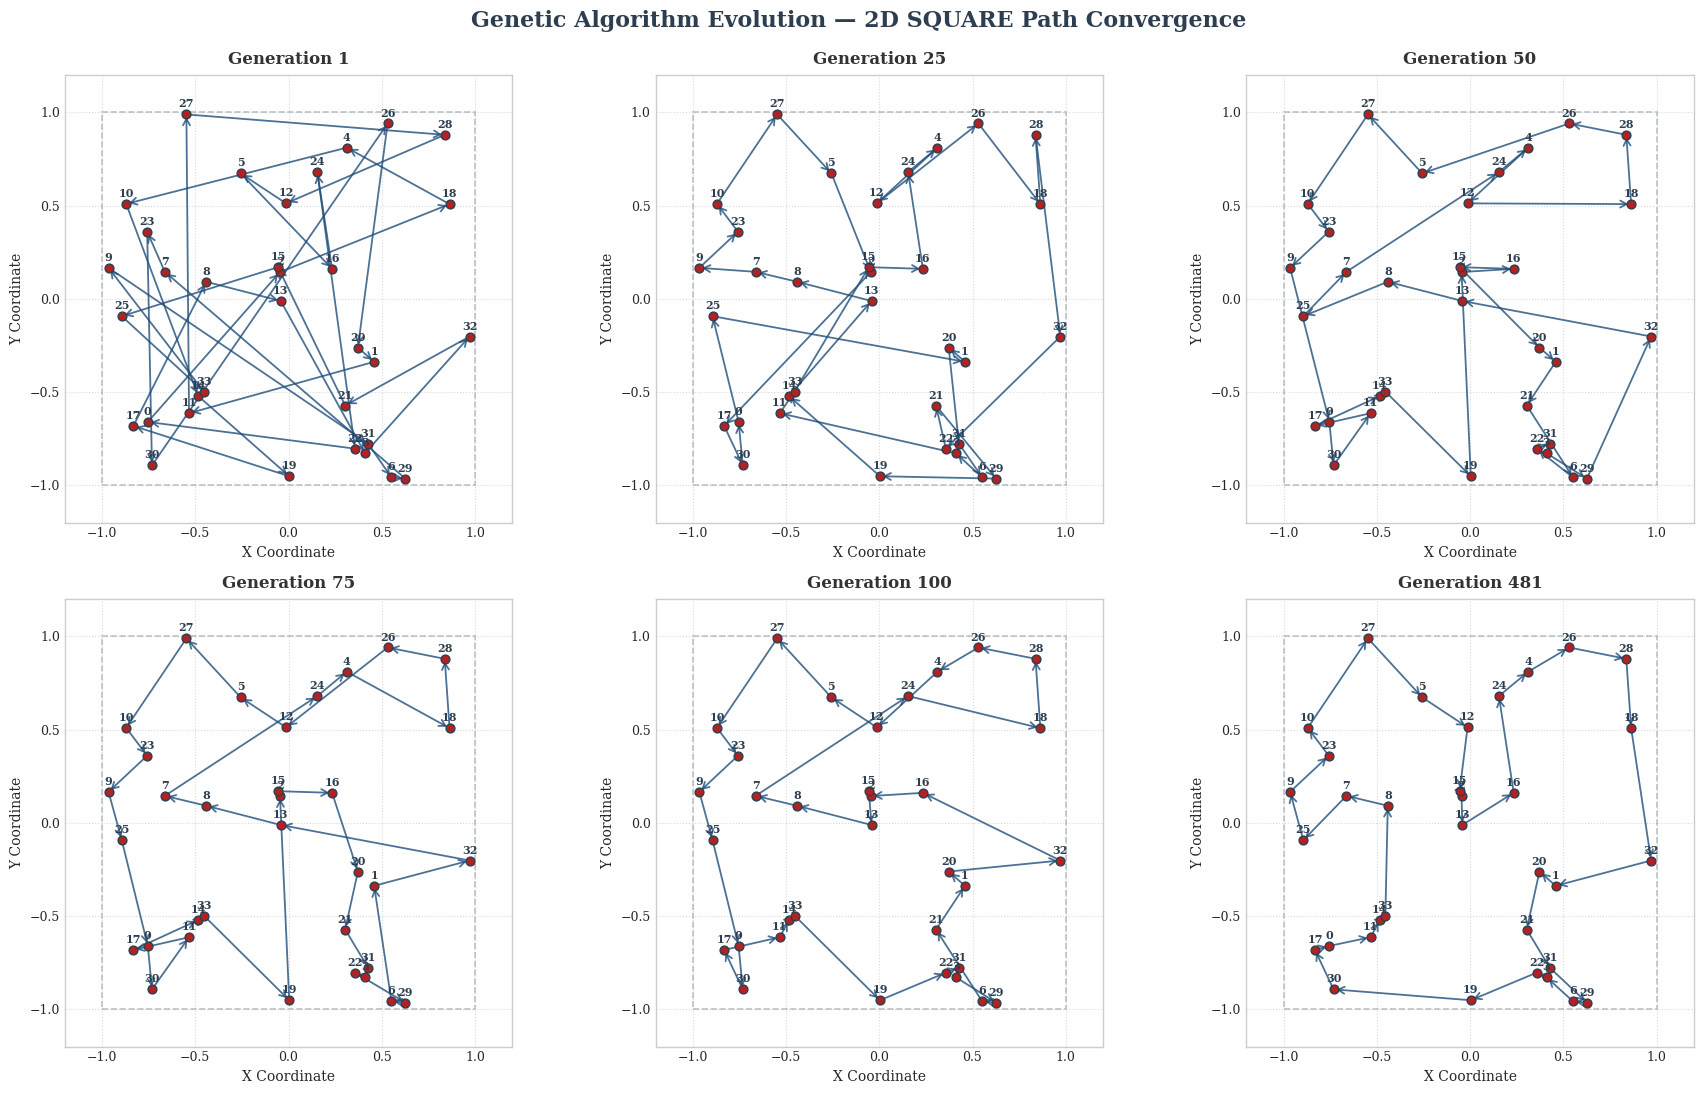


Caricamento dati di loss (SQUARE)...
🎉 Grafico formale delle loss salvato in: IMAGES/LossFunctionSquare.png


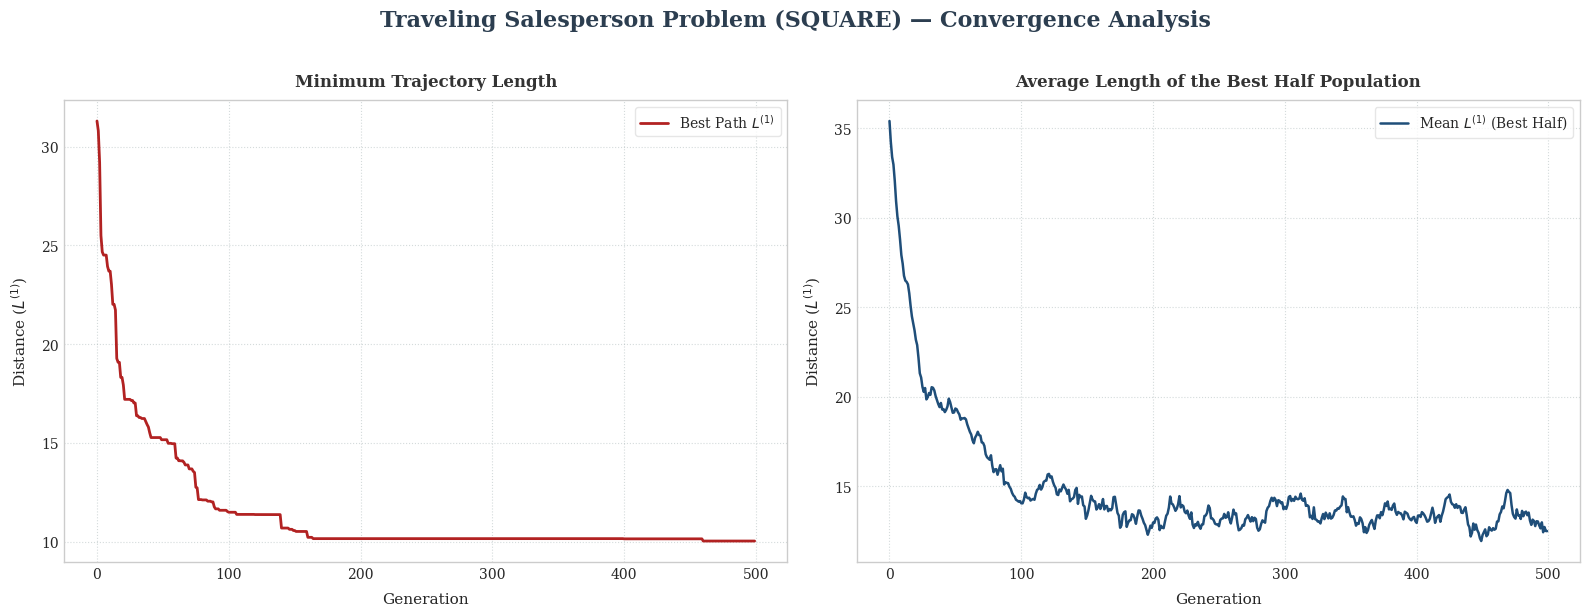

In [7]:
BASE_DIR = "SQUARE/OUTPUT/"
file_cities = os.path.join(BASE_DIR, "CitiesInfo.dat")
gen_folder = os.path.join(BASE_DIR, "GENERATIONS2/")

BEST_PATH = os.path.join(BASE_DIR, "STAT/BestL1.dat")
HALF_PATH = os.path.join(BASE_DIR, "STAT/HalfL1.dat")

# Generazioni selezionate per la griglia 2x3
generazioni_plot = [0, 24, 49, 74, 99, 480]

# Configurazione globale dello stile accademico/formale
plt.rcParams['font.family'] = 'serif'
COLOR_PATH = "#1f4e79"                 # Blu notte istituzionale per le traiettorie
COLOR_CITY = "#b22222"                 # Rosso scuro accademico per le città
GRID_STYLE = {'linestyle': ':', 'alpha': 0.4, 'color': '#95a5a6'}

try:
    if not os.path.exists(file_cities):
        raise FileNotFoundError(f"File città non trovato: {file_cities}")
        
    # Paracadute per le intestazioni di testo
    try:
        dati = np.loadtxt(file_cities)
    except ValueError:
        print("⚠️ Trovata intestazione di testo in CitiesInfo.dat. La salto automaticamente.")
        dati = np.loadtxt(file_cities, skiprows=1)
        
    labels = dati[:, 0].astype(int)
    x = dati[:, 1]
    y = dati[:, 2]
    
    # Mappatura solida a doppia chiave (sia per indici 0-based che 1-based)
    city_coords = {}
    for i in range(len(labels)):
        lbl = int(labels[i])
        city_coords[lbl] = (x[i], y[i])
        city_coords[i] = (x[i], y[i])


    fig, axes = plt.subplots(2, 3, figsize=(18, 11)) 
    axes_flat = axes.flatten() 

    for idx, gen in enumerate(generazioni_plot):
        ax = axes_flat[idx]
        
        # Generazione dinamica del percorso file
        file_attuale = os.path.join(gen_folder, f"PopulationGeneration{gen}.dat")
        
        if not os.path.exists(file_attuale):
            print(f"⚠️ File mancante per Gen {gen}: {file_attuale}. Salto il subplot.")
            ax.set_title(f"Gen {gen} (Not Found)", fontsize=11, color='gray', fontstyle='italic')
            continue

        # Lettura file di percorso
        with open(file_attuale, 'r') as file:
            prima_riga = file.readline().strip()
            percorso_str = file.readline().strip() if "Distanze" in prima_riga else prima_riga
        
        ordine_visita = [int(num) for num in percorso_str.split() if num.strip().isdigit()]
        
        if ordine_visita:
            ordine_visita.append(ordine_visita[0]) # Chiusura del cammino hamiltoniano

        # Riferimento geometrico di sfondo: Il Quadrato di vincolo (lato = 2.0, centrato in 0,0)
        quadrato = patches.Rectangle((-1.0, -1.0), 2.0, 2.0, color='#bdc3c7', fill=False, linestyle='--', linewidth=1.2, zorder=0)
        ax.add_patch(quadrato)

        # Tracciamento traiettoria con vettori orientati
        for i in range(len(ordine_visita) - 1):
            id_corrente = ordine_visita[i]
            id_successivo = ordine_visita[i+1]
            
            if id_corrente in city_coords and id_successivo in city_coords:
                x_start, y_start = city_coords[id_corrente]
                x_end, y_end = city_coords[id_successivo]
                
                freccia = patches.FancyArrowPatch(
                    (x_start, y_start), (x_end, y_end),
                    connectionstyle="arc3,rad=0.0", color=COLOR_PATH, alpha=0.8,
                    arrowstyle="->,head_width=2.5,head_length=4.5", linewidth=1.3, zorder=1
                )
                ax.add_patch(freccia)
            else:
                print(f"⚠️ Impossibile tracciare la tratta: città {id_corrente} o {id_successivo} mancante.")

        # Plot nodi urbani ed etichette numeriche
        ax.scatter(x, y, color=COLOR_CITY, marker='o', edgecolors='#2c3e50', s=40, zorder=2)
        for i in range(len(x)):
            ax.annotate(str(labels[i]), (x[i], y[i]), textcoords="offset points", 
                        xytext=(0, 5), ha='center', fontsize=8, fontweight='bold', color='#2c3e50', zorder=3)

        # Configurazione estetica degli assi del subplot
        ax.set_title(f"Generation {gen + 1}", fontsize=12, fontweight='bold', pad=8, color='#333333')
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        ax.set_xlabel("X Coordinate", fontsize=10, labelpad=4)
        ax.set_ylabel("Y Coordinate", fontsize=10, labelpad=4)
        ax.grid(True, **GRID_STYLE)
        ax.tick_params(labelsize=9)

    # Titolo globale della figura (Parte 1)
    fig.suptitle("Genetic Algorithm Evolution — 2D SQUARE Path Convergence", 
                 fontsize=16, fontweight='bold', color='#2c3e50', y=0.99)
    
    os.makedirs("IMAGES", exist_ok=True)
    plt.tight_layout()  
    plt.savefig("IMAGES/SQUAREPaths.png", dpi=300, bbox_inches='tight')
    print("🎉 Griglia formale dei percorsi salvata in: IMAGES/SQUAREPaths.png")
    plt.show()

except Exception as e:
    print(f"❌ Errore nella PARTE 1: {e}")

try:
    if not os.path.exists(BEST_PATH) or not os.path.exists(HALF_PATH):
        raise FileNotFoundError("File BestL1.dat o HalfL1.dat mancanti in SQUARE/OUTPUT/STAT/")

    print("\nCaricamento dati di loss (SQUARE)...")
    
    # Funzione di protezione per caricare le statistiche ignorando testo e colonne extra
    def carica_dati_stat(percorso):
        try:
            return np.loadtxt(percorso, unpack=True, usecols=(0, 1))
        except ValueError:
            print(f"⚠️ Trovata intestazione di testo in {os.path.basename(percorso)}. La salto automaticamente.")
            return np.loadtxt(percorso, unpack=True, usecols=(0, 1), skiprows=1)

    gen_best, dist_best = carica_dati_stat(BEST_PATH)
    gen_half, dist_half = carica_dati_stat(HALF_PATH)

    fig_loss, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
    fig_loss.suptitle("Traveling Salesperson Problem (SQUARE) — Convergence Analysis", 
                       fontsize=16, fontweight='bold', color='#2c3e50', y=1.02)

    # --- Grafico 1: Lunghezza del percorso migliore ---
    ax1.plot(gen_best, dist_best, color=COLOR_CITY, linewidth=2.0, label=r"Best Path $L^{(1)}$")
    ax1.set_title("Minimum Trajectory Length", fontsize=12, fontweight='bold', pad=10, color='#333333')
    ax1.set_xlabel("Generation", fontsize=11, labelpad=8)
    ax1.set_ylabel("Distance ($L^{(1)}$)", fontsize=11, labelpad=8)
    ax1.grid(True, **GRID_STYLE)
    ax1.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='#e0e0e0', fontsize=10)
    ax1.tick_params(labelsize=10)

    # --- Grafico 2: Media della metà migliore della popolazione ---
    ax2.plot(gen_half, dist_half, color=COLOR_PATH, linewidth=1.8, label=r"Mean $L^{(1)}$ (Best Half)")
    ax2.set_title("Average Length of the Best Half Population", fontsize=12, fontweight='bold', pad=10, color='#333333')
    ax2.set_xlabel("Generation", fontsize=11, labelpad=8)
    ax2.set_ylabel("Distance ($L^{(1)}$)", fontsize=11, labelpad=8)
    ax2.grid(True, **GRID_STYLE)
    ax2.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='#e0e0e0', fontsize=10)
    ax2.tick_params(labelsize=10)

    # --- Salvataggio (Parte 2) ---
    plt.tight_layout()  
    plt.savefig("IMAGES/LossFunctionSquare.png", dpi=300, bbox_inches='tight')
    print("🎉 Grafico formale delle loss salvato in: IMAGES/LossFunctionSquare.png")
    plt.show()

except FileNotFoundError as e:
    print(f"❌ Errore nella PARTE 2: {e}")
except Exception as e:
    print(f"❌ Errore imprevisto nella PARTE 2: {e}")

Like in exercise 9.2 we find that the algorithm struggles in finding the shortest path out all possible paths after the first $100$ generations, however it is possible to observe a faster decrease of the length of the shortest pattern (chosen from a the process having the shortest length).

### Exercise 10.2

For exercise 10.2 it is important to not fall in the trap of ***overmigrating***. Overmigration occurs when the processes exchange to often their best individuals and doesn't allow the core to work enough independently to explore the configuration space. Essentially what happens is that the the processes explore circa the same region of the configuration space and as a consequence arrive at the same results. The results of the best distances for each rank are presented in `OUTPUT/ranking_processes.dat`. For the simulation I used the following parameters (with $N_{cities}$ = $110$): 

| Parameter | Value | Description |
| :--- | :---: | :--- |
| **SIM_TYPE** | 1 | Simulation geometry type (Square map setup) |
| **TOT_INDIVID** | 300 | Total number of individual trajectories per continent |
| **N_GENERATIONS** | 1000 | Total number of evolutionary generations |
| **P_VALUE** | 4.0 | Exponent factor for the selection operator algorithm |
| **CROSSOVER_PROB** | 0.8 | Probability threshold for genetic crossover (80%) |
| **SWAP_PROB** | 0.23 | Probability threshold for pairwise city swap mutation (23%) |
| **SHIFT_PROB** | 0.2 | Probability threshold for city block shift mutation (20%) |
| **PERM_PROB** | 0.10 | Probability threshold for independent block permutation mutation (10%) |
| **REVERSE_PROB** | 0.15 | Probability threshold for sequence order reversal mutation (15%) |

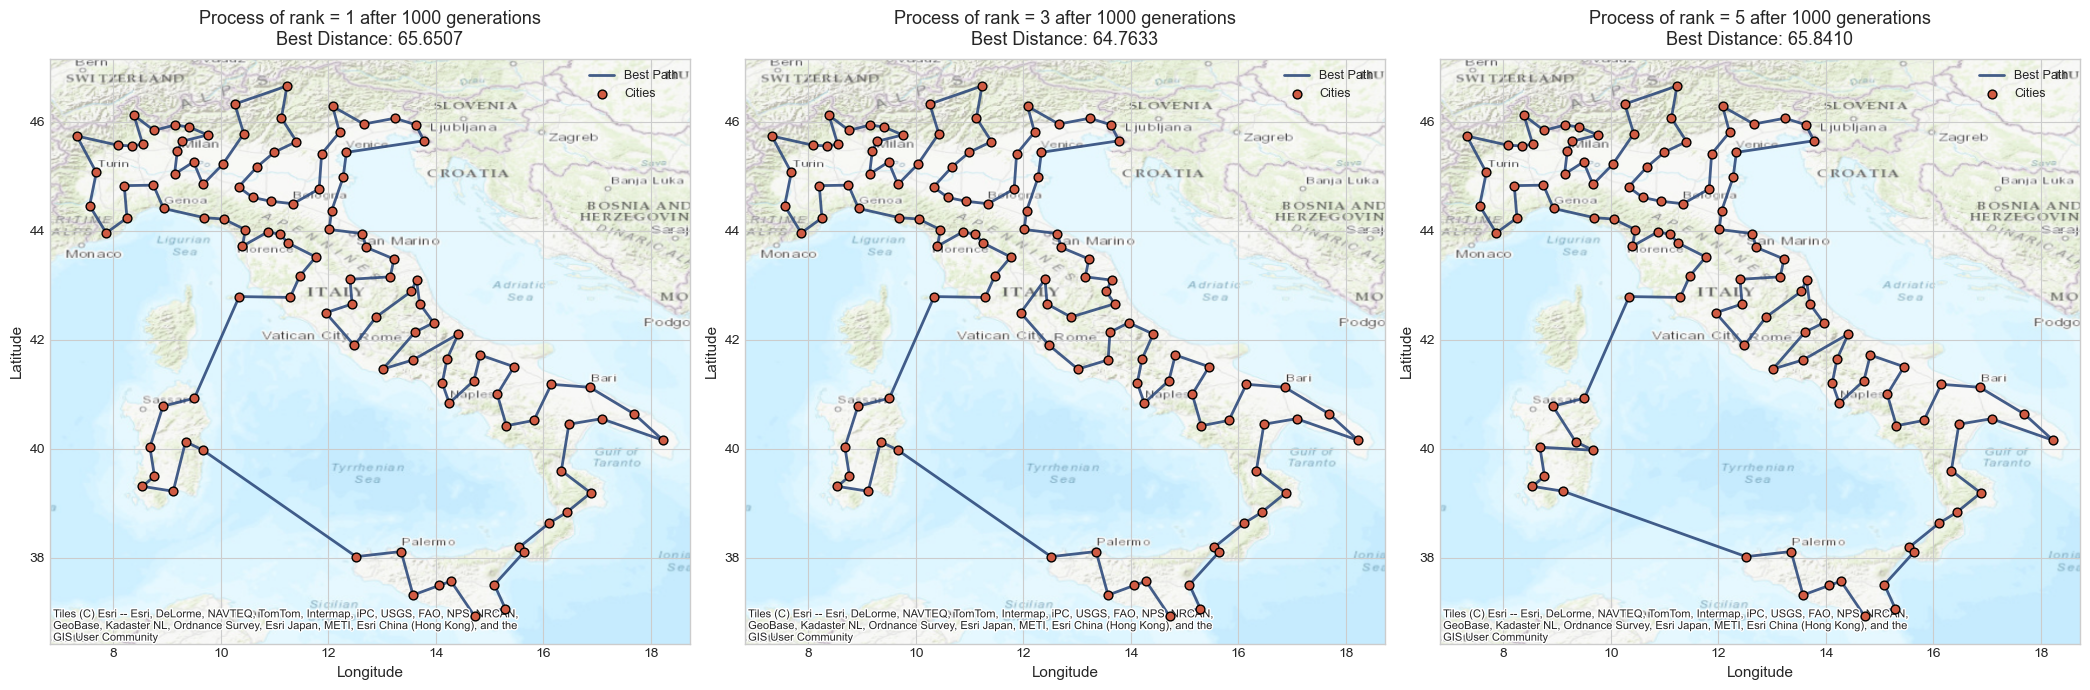

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
import re
import os

# ==========================================
# Configurazione iniziale
# ==========================================
processes_to_plot = [1, 3, 5]
x_cities, y_cities = np.loadtxt("10.2/cap_prov_ita.dat", unpack=True)
ranking_file = "10.2/OUTPUT/ranking_processes.dat"

# Legge il file di ranking per recuperare le distanze
ranking_data = {}
try:
    with open(ranking_file, "r") as f:
        for line in f.readlines():
            match_rank = re.search(r'Rank\s+(\d+)\s*->\s*Best Distance:\s*([\d.]+)', line)
            if match_rank:
                rank_id = int(match_rank.group(1))
                dist = float(match_rank.group(2))
                ranking_data[rank_id] = dist
except FileNotFoundError:
    print(f"Warning: File {ranking_file} not found.")

# ==========================================
# Creazione della figura con 3 subplot affiancati
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# Calcoliamo i confini geografici comuni per la mappa
margin = 0.5
x_min, x_max = x_cities.min() - margin, x_cities.max() + margin
y_min, y_max = y_cities.min() - margin, y_cities.max() + margin

for idx, rank_id in enumerate(processes_to_plot):
    ax = axes[idx]
    
    # Impostiamo i limiti degli assi PRIMA di aggiungere la mappa di contextily
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    path_to_gen = f"10.2/OUTPUT/GENERATIONS{rank_id}/PopulationGeneration999.dat"
    
    # Caricamento del percorso migliore
    try:
        with open(path_to_gen, "r") as f:
            first_line = f.readline()
        best_path = np.array([int(i) for i in first_line.split()])
        x_path = x_cities[best_path]
        y_path = y_cities[best_path]
        
        # Chiusura del percorso
        x_path = np.append(x_path, x_path[0])
        y_path = np.append(y_path, y_path[0])
    except FileNotFoundError:
        print(f"Warning: File {path_to_gen} not found.")
        continue

    # Disegno del percorso
    ax.plot(x_path, y_path, linestyle='-', marker='', color='#2F4B7C', alpha=0.9, linewidth=2, label='Best Path')
    
    # Disegno delle città
    ax.scatter(x_cities, y_cities, color='#D05B43', s=40, label='Cities', zorder=5, edgecolors='black')

    # Aggiunta della mappa di sfondo
    cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.Esri.WorldTopoMap, alpha=0.8)

    # Titolo e etichette in inglese
    best_distance = ranking_data.get(rank_id, None)
    title_str = f'Process of rank = {rank_id} after 1000 generations'
    if best_distance is not None:
        title_str += f'\nBest Distance: {best_distance:.4f}'
        
    ax.set_title(title_str, fontsize=13, pad=10)
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.legend(fontsize=9, loc='upper right')

# Assicura che la cartella IMAGES esista prima di salvare
os.makedirs("IMAGES", exist_ok=True)

# Ottimizzazione dei margini, salvataggio e visualizzazione
plt.tight_layout()
plt.savefig("IMAGES/PlotTrajRank10.2.png", dpi=300)
plt.show()


Caricamento dati di loss (10.2)...
🎉 Grafico formale delle loss salvato con successo in: IMAGES/LossFunctionCircle.png


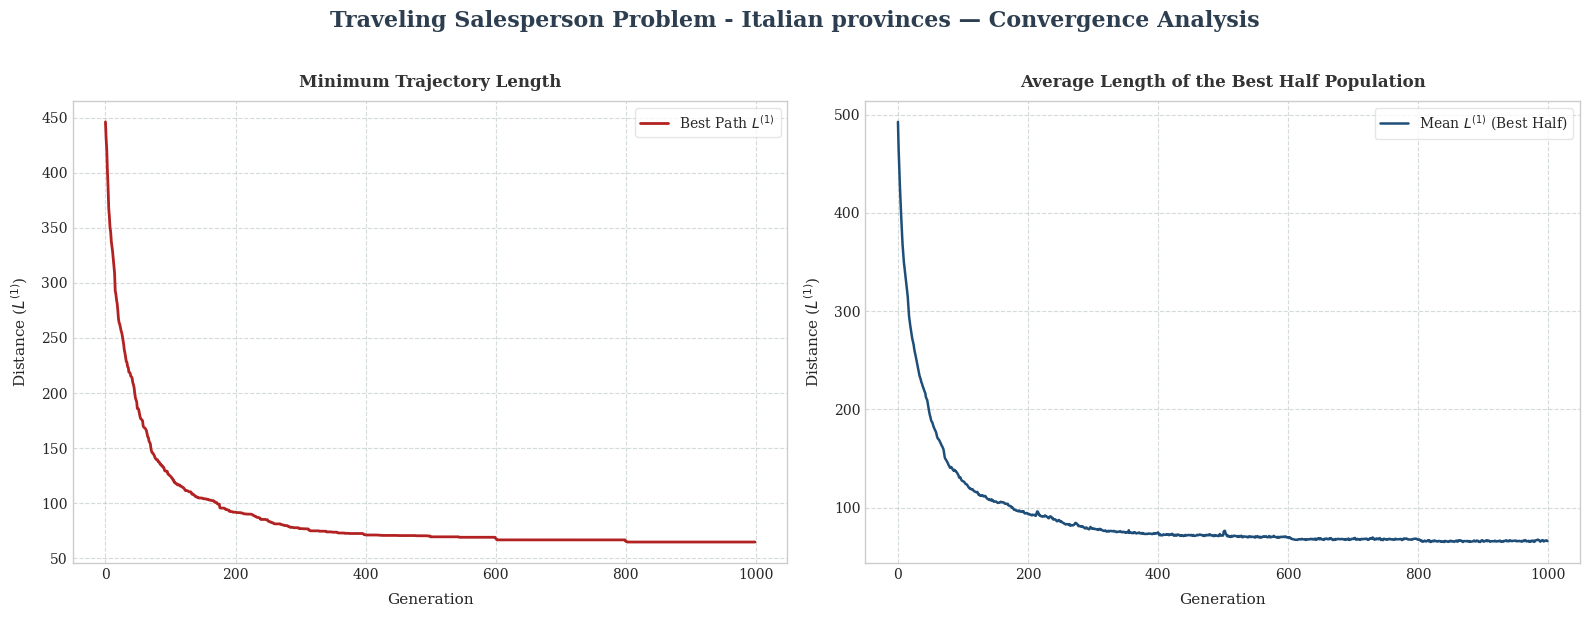

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
BASE_DIR = "10.2/OUTPUT/"
file_cities = os.path.join(BASE_DIR, "CitiesInfo.dat")
gen_folder = os.path.join(BASE_DIR, "GENERATIONS2/")

BEST_PATH = os.path.join(BASE_DIR, "STAT/BestL1.dat")
HALF_PATH = os.path.join(BASE_DIR, "STAT/HalfL1.dat")


try:
    if not os.path.exists(BEST_PATH) or not os.path.exists(HALF_PATH):
        raise FileNotFoundError("File BestL1.dat o HalfL1.dat mancanti in 10.2/OUTPUT/STAT/")

    print("\nCaricamento dati di loss (10.2)...")
    
    # Funzione di protezione per caricare i dati ignorando intestazioni e colonne extra
    def carica_dati_stat(percorso):
        try:
            # Forza la lettura delle sole prime due colonne (Generazione, Distanza)
            return np.loadtxt(percorso, unpack=True, usecols=(0, 1))
        except ValueError:
            print(f"⚠️ Trovata intestazione di testo in {os.path.basename(percorso)}. La salto automaticamente.")
            return np.loadtxt(percorso, unpack=True, usecols=(0, 1), skiprows=1)

    gen_best, dist_best = carica_dati_stat(BEST_PATH)
    gen_half, dist_half = carica_dati_stat(HALF_PATH)

    # --- CONFIGURAZIONE STILE FORMALE ---
    plt.rcParams['font.family'] = 'serif'  # Font graffiato elegante/scientifico
    COLOR_BEST = "#b22222"                 # Rosso scuro accademico (Burgundy)
    COLOR_HALF = "#1f4e79"                 # Blu notte istituzionale
    GRID_STYLE = {'linestyle': '--', 'alpha': 0.4, 'color': '#95a5a6'}

    fig_loss, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
    fig_loss.suptitle("Traveling Salesperson Problem - Italian provinces — Convergence Analysis", 
                       fontsize=16, fontweight='bold', color='#2c3e50', y=1.02)

    # --- Grafico 1: Lunghezza del percorso migliore ---
    ax1.plot(gen_best, dist_best, color=COLOR_BEST, linewidth=2.0, label=r"Best Path $L^{(1)}$")
    ax1.set_title("Minimum Trajectory Length", fontsize=12, fontweight='bold', pad=10, color='#333333')
    ax1.set_xlabel("Generation", fontsize=11, labelpad=8)
    ax1.set_ylabel("Distance ($L^{(1)}$)", fontsize=11, labelpad=8)
    ax1.grid(True, **GRID_STYLE)
    ax1.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='#e0e0e0', fontsize=10)
    ax1.tick_params(labelsize=10)

    # --- Grafico 2: Media della metà migliore della popolazione ---
    ax2.plot(gen_half, dist_half, color=COLOR_HALF, linewidth=1.8, label=r"Mean $L^{(1)}$ (Best Half)")
    ax2.set_title("Average Length of the Best Half Population", fontsize=12, fontweight='bold', pad=10, color='#333333')
    ax2.set_xlabel("Generation", fontsize=11, labelpad=8)
    ax2.set_ylabel("Distance ($L^{(1)}$)", fontsize=11, labelpad=8)
    ax2.grid(True, **GRID_STYLE)
    ax2.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='#e0e0e0', fontsize=10)
    ax2.tick_params(labelsize=10)

    # --- SALVATAGGIO OTTIMIZZATO ---
    os.makedirs("IMAGES", exist_ok=True)
    plt.tight_layout()  # Organizza gli spazi prima del salvataggio
    plt.savefig("IMAGES/LossFunctionCircle.png", dpi=300, bbox_inches='tight')
    print("🎉 Grafico formale delle loss salvato con successo in: IMAGES/LossFunctionCircle.png")
    plt.show()

except FileNotFoundError as e:
    print(f"❌ Errore nella PARTE 2: {e}")
except Exception as e:
    print(f"❌ Errore imprevisto nella PARTE 2: {e}")

The lowest value I found out of all trajectories was $64.7633$.


However working with the following hyperparameters I found a value of distance $= 64.723$ for all processes:

| Parameter | Value | Description |
| :--- | :---: | :--- |
| **SIM_TYPE** | 1 | Simulation geometry type (Square map setup) |
| **TOT_INDIVID** | 300 | Total number of individual trajectories per continent |
| **N_GENERATIONS** | 5000 | Total number of evolutionary generations |
| **P_VALUE** | 3.5 | Exponent factor for the selection operator algorithm |
| **CROSSOVER_PROB** | 0.8 | Probability threshold for genetic crossover (80%) |
| **SWAP_PROB** | 0.23 | Probability threshold for pairwise city swap mutation (23%) |
| **SHIFT_PROB** | 0.2 | Probability threshold for city block shift mutation (20%) |
| **PERM_PROB** | 0.10 | Probability threshold for independent block permutation mutation (10%) |
| **REVERSE_PROB** | 0.15 | Probability threshold for sequence order reversal mutation (15%) |

Below is the plot of the trajectory that yields a value of $64.723$



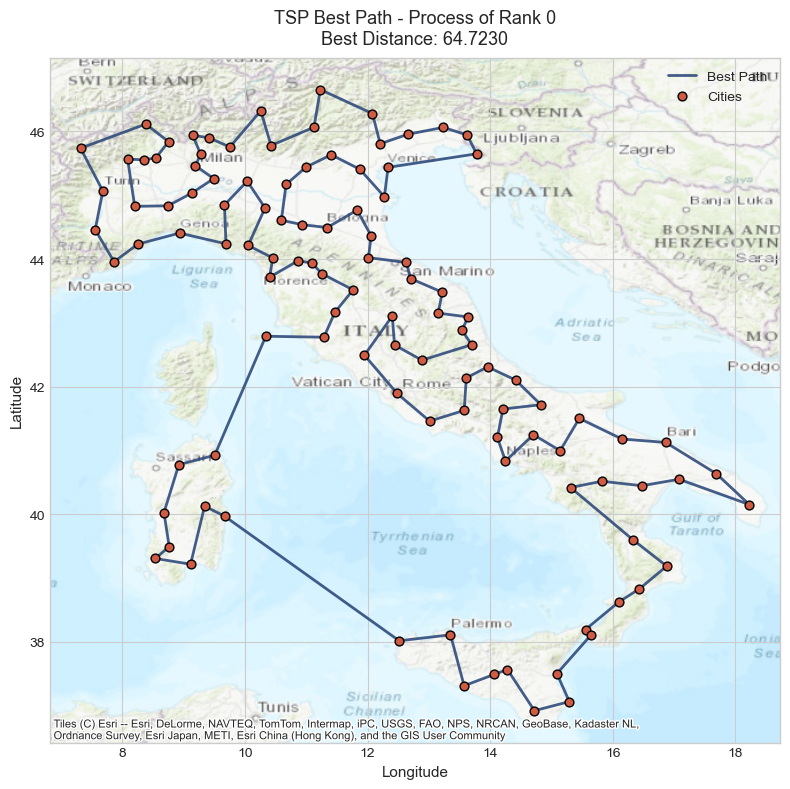

In [26]:

target_rank = 0
x_cities, y_cities = np.loadtxt("OUTPUT10.2NEW/cap_prov_ita.dat", unpack=True)
ranking_file = "OUTPUT10.2NEW/ranking_processes.dat"

# Legge il file di ranking per recuperare la distanza del Rank 0
best_distance = None
try:
    with open(ranking_file, "r") as f:
        for line in f.readlines():
            match_rank = re.search(r'Rank\s+(\d+)\s*->\s*Best Distance:\s*([\d.]+)', line)
            if match_rank:
                rank_id = int(match_rank.group(1))
                if rank_id == target_rank:
                    best_distance = float(match_rank.group(2))
                    break
except FileNotFoundError:
    print(f"Warning: File {ranking_file} not found.")


plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 8))

# Calcoliamo un margine per i confini geografici della mappa
margin = 0.5
ax.set_xlim(x_cities.min() - margin, x_cities.max() + margin)
ax.set_ylim(y_cities.min() - margin, y_cities.max() + margin)

path_to_gen = f"OUTPUT10.2NEW/GENERATIONS{target_rank}/PopulationGeneration999.dat"

# Caricamento del percorso migliore
try:
    with open(path_to_gen, "r") as f:
        first_line = f.readline()
    best_path = np.array([int(i) for i in first_line.split()])
    x_path = x_cities[best_path]
    y_path = y_cities[best_path]
    
    # Chiusura del ciclo TSP (tornando alla città di partenza)
    x_path = np.append(x_path, x_path[0])
    y_path = np.append(y_path, y_path[0])
except FileNotFoundError:
    print(f"Warning: File {path_to_gen} not found.")
    exit()

# Disegno del percorso migliore
ax.plot(x_path, y_path, linestyle='-', marker='', color='#2F4B7C', alpha=0.9, linewidth=2, label='Best Path')

# Disegno delle città
ax.scatter(x_cities, y_cities, color='#D05B43', s=40, label='Cities', zorder=5, edgecolors='black')

# Aggiunta della mappa di sfondo
cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.Esri.WorldTopoMap, alpha=0.8)

# Titolo e etichette
title_str = f'TSP Best Path - Process of Rank {target_rank}'
if best_distance is not None:
    title_str += f'\nBest Distance: {best_distance:.4f}'
    
ax.set_title(title_str, fontsize=13, pad=10)
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.legend(fontsize=10, loc='upper right')

# Ottimizzazione dei margini e visualizzazione
plt.tight_layout()
plt.savefig("IMAGES/TrajBestDistance.png")
plt.show()